<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (105, 4)
Teste: (45, 4)


# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Acurácia treino:", train_acc)
print("Acurácia teste:", test_acc)

Acurácia treino: 1.0
Acurácia teste: 0.9333333333333333


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

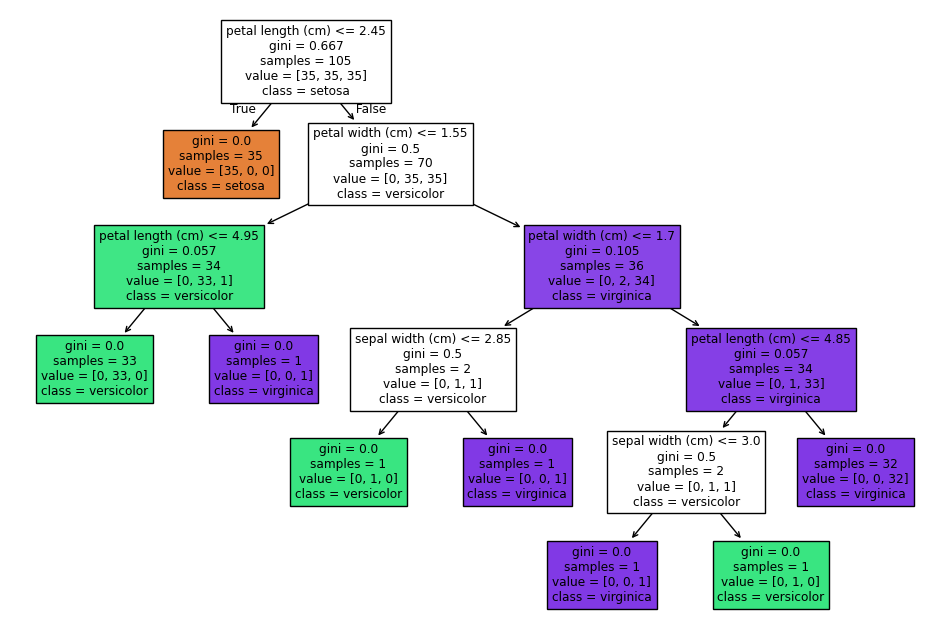

Profundidade: 5


In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.show()

print("Profundidade:", model.get_depth())

**Adicione seu texto de solução aqui**.

Atributo na raiz: petal length (cm)
Profundidade da árvore: 5

# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [ ]:
import pandas as pd

results = []

depths = list(range(1,10)) + [None]

for d in depths:

    model = DecisionTreeClassifier(max_depth=d, random_state=42)

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    depth = model.get_depth()
    leaves = model.get_n_leaves()

    results.append([d, train_acc, test_acc, depth, leaves])

df = pd.DataFrame(
    results,
    columns=["max_depth","train_acc","test_acc","depth","leaves"]
)

print(df)

,max_depth,train_acc,test_acc,depth,leaves
0,1.0,0.666667,0.666667,1,2
1,2.0,0.971429,0.888889,2,3
2,3.0,0.980952,0.977778,3,5
3,4.0,0.990476,0.888889,4,7
4,5.0,1.000000,0.933333,5,8
5,6.0,1.000000,0.933333,5,8
6,7.0,1.000000,0.933333,5,8
7,8.0,1.000000,0.933333,5,8
8,9.0,1.000000,0.933333,5,8
9,NaN,1.000000,0.933333,5,8


**Em qual profundidade começa o overfitting?**
**Por que a árvore consegue 100% no treino quando max_depth=None?**

Quando a profundidade aumenta:

- treino tende a chegar a 100%
- teste pode cair

Isso acontece por overfitting, quando o modelo se ajusta demais ao dataset de treino.

# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [ ]:
gini_model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

entropy_model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

gini_model.fit(X_train, y_train)
entropy_model.fit(X_train, y_train)

gini_acc = accuracy_score(y_test, gini_model.predict(X_test))
entropy_acc = accuracy_score(y_test, entropy_model.predict(X_test))

print("Gini accuracy:", gini_acc)
print("Entropy accuracy:", entropy_acc)

print("Gini depth:", gini_model.get_depth())
print("Entropy depth:", entropy_model.get_depth())

Gini accuracy: 0.9333333333333333
Entropy accuracy: 0.8888888888888888
Gini depth: 5
Entropy depth: 6


# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

In [ ]:
depths = range(1,11)

best_acc = 0
best_depth = None

for d in depths:

    model = DecisionTreeClassifier(
        max_depth=d,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    print("max_depth:", d, "accuracy:", acc)

    if acc > best_acc:
        best_acc = acc
        best_depth = d

print("Melhor profundidade:", best_depth)
print("Melhor acurácia:", best_acc)

max_depth: 1 accuracy: 0.6666666666666666
max_depth: 2 accuracy: 0.8888888888888888
max_depth: 3 accuracy: 0.9777777777777777
max_depth: 4 accuracy: 0.8888888888888888
max_depth: 5 accuracy: 0.9333333333333333
max_depth: 6 accuracy: 0.9333333333333333
max_depth: 7 accuracy: 0.9333333333333333
max_depth: 8 accuracy: 0.9333333333333333
max_depth: 9 accuracy: 0.9333333333333333
max_depth: 10 accuracy: 0.9333333333333333
Melhor profundidade: 3
Melhor acurácia: 0.9777777777777777
